In [2]:
import re
import requests
import string
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import tiktoken

# GPT4 Tokenizer

In [3]:
book = requests.get("https://www.gutenberg.org/files/35/35-0.txt").text

# character strings to replace with spaces
strings2replace = ['\r\n\r\nâ\x80\x9c',
                   'â\x80\x9c',
                   'â\x80\x9d',
                   '\r\n',
                   'â\x80\x94',
                   'â\x80\x99',
                   'â\x80\x98','_', ]

# here we are cleaning the text, but normally this is done by the tokenizer
for str2match in strings2replace:
    book = re.sub(str2match, ' ', book) # using regex to replace all occurrences of the string with a space

# remove non-ASCII characters
book = re.sub(r'[^\x00-\x7F]+', ' ', book)

In [4]:
# cl100k_base is the tokenizer used by GPT-4, which is a BPE tokenizer that can handle a wide range of characters and is optimized for English text. 
# It has a vocabulary of around 100,000 tokens, which allows it to represent common words, subwords, and even some rare words efficiently.
tokenizer = tiktoken.get_encoding("cl100k_base") 
print(f"Encoded 'Hello, world!': {tokenizer.encode('Hello, world!')}")

# check what it means every token ID in "Hello, world!"
for token_id in tokenizer.encode("Hello, world!"):
    print(f"Token ID: {token_id}, Token: '{tokenizer.decode([token_id])}'")

Encoded 'Hello, world!': [9906, 11, 1917, 0]
Token ID: 9906, Token: 'Hello'
Token ID: 11, Token: ','
Token ID: 1917, Token: ' world'
Token ID: 0, Token: '!'


In [15]:
# how many r's in "strawberry"?
strawberry_token = tokenizer.encode("strawberry")
r_token = tokenizer.encode("r")[0]

for t in strawberry_token:
    print(f"Token ID: {t}, Token: '{tokenizer.decode([t])}'")

print(f"Token ID: {r_token}, Token: '{tokenizer.decode([r_token])}'")

print("-"*30)

# chatgpt cannot solve this using its internal representation / tokenizer
print(r_token in strawberry_token)

# instead it will use code to count the number of r's in "strawberry"
strawberry_str = tokenizer.decode(strawberry_token)
r_string = tokenizer.decode([r_token])
r_count = strawberry_str.count(r_string)
print(f"Number of 'r's in 'strawberry': {r_count}")

Token ID: 496, Token: 'str'
Token ID: 675, Token: 'aw'
Token ID: 15717, Token: 'berry'
Token ID: 81, Token: 'r'
------------------------------
False
Number of 'r's in 'strawberry': 3


In [4]:
# print end of text token. This is a special token that the model uses to know when the input text ends. 
# It is important for the model to understand when to stop generating text.
eot_token_id = tokenizer.eot_token
print(f"End of text token ID: {eot_token_id}, which means: '{tokenizer.decode([eot_token_id])}'")

End of text token ID: 100257, which means: '<|endoftext|>'


In [5]:
# vocab size of the tokenizer
print(f"Vocabulary size of the tokenizer: {tokenizer.n_vocab}")

# however not all tokens are available in the tokenizer, for example the token ID 100261 is not in the tokenizer.
# This means that the tokenizer will not be able to decode this token ID, and it will return an empty string.
# This is done to make the tokenizer suitable for future updates

#tokenizer.decode([100261])

Vocabulary size of the tokenizer: 100277


In [6]:
text = "I like toothpaste-flavored ice cream"
tokens = tokenizer.encode(text)

for word in text.split():
    print(f"Token ID for '{word}': {tokenizer.encode(word)}") 
    # we can see that some words are tokenized as a single token, while others are split into multiple tokens. 

# visualize how the tokenizer splits the word "toothpaste-flavored" into tokens
print("-"*50)
for t in tokenizer.encode("toothpaste-flavored"):
    print(f"Token ID: {t}, Token: '{tokenizer.decode([t])}'")

Token ID for 'I': [40]
Token ID for 'like': [4908]
Token ID for 'toothpaste-flavored': [998, 8942, 57968, 12556, 76486]
Token ID for 'ice': [560]
Token ID for 'cream': [47100]
--------------------------------------------------
Token ID: 998, Token: 'to'
Token ID: 8942, Token: 'oth'
Token ID: 57968, Token: 'paste'
Token ID: 12556, Token: '-fl'
Token ID: 76486, Token: 'avored'


Error decoding token ID 100256: 'Invalid token for decoding: 100256'
Error decoding token ID 100261: 'Invalid token for decoding: 100261'
Error decoding token ID 100262: 'Invalid token for decoding: 100262'
Error decoding token ID 100263: 'Invalid token for decoding: 100263'
Error decoding token ID 100264: 'Invalid token for decoding: 100264'
Error decoding token ID 100265: 'Invalid token for decoding: 100265'
Error decoding token ID 100266: 'Invalid token for decoding: 100266'
Error decoding token ID 100267: 'Invalid token for decoding: 100267'
Error decoding token ID 100268: 'Invalid token for decoding: 100268'
Error decoding token ID 100269: 'Invalid token for decoding: 100269'
Error decoding token ID 100270: 'Invalid token for decoding: 100270'
Error decoding token ID 100271: 'Invalid token for decoding: 100271'
Error decoding token ID 100272: 'Invalid token for decoding: 100272'
Error decoding token ID 100273: 'Invalid token for decoding: 100273'
Error decoding token ID 100274: 'I

Text(0.5, 1.0, 'Distribution of token lengths in the tokenizer')

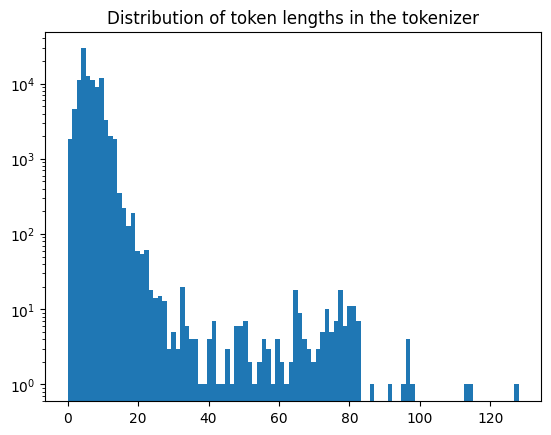

In [7]:
# check the length of every token in the tokenizer
# be aware that some tokens are special tokens that do not correspond to any text, and they will be decoded as an empty string.
token_lengths = np.zeros(tokenizer.n_vocab, dtype=int)
for token_id in range(tokenizer.n_vocab):
    try:
        token = tokenizer.decode([token_id])
        token_lengths[token_id] = len(token)
    except Exception as e:
        print(f"Error decoding token ID {token_id}: {e}")

plt.hist(token_lengths, bins=100, log=True)
plt.title("Distribution of token lengths in the tokenizer")

In [8]:
# tokens can differ if they start with a space or not. e.g. " hello" and "hello"
print(f"Token ID for 'hello': {tokenizer.encode('hello')}")
print(f"Token ID for ' hello': {tokenizer.encode(' hello')}")

Token ID for 'hello': [15339]
Token ID for ' hello': [24748]


In [9]:
tokens = tokenizer.encode(book)
print(f"Number of tokens in the book: {len(tokens)}")
print(f"Number of unique tokens in the book: {len(set(tokens))}")

for t in book.split()[:10]:
    print(f"Token ID for '{t}': {tokenizer.encode(t)}")

Number of tokens in the book: 40264
Number of unique tokens in the book: 5257
Token ID for '***': [12488]
Token ID for 'START': [23380]
Token ID for 'OF': [12766]
Token ID for 'THE': [17673]
Token ID for 'PROJECT': [42555]
Token ID for 'GUTENBERG': [38, 1406, 965, 9745, 38]
Token ID for 'EBOOK': [36, 37725]
Token ID for '35': [1758]
Token ID for '***': [12488]
Token ID for 'The': [791]


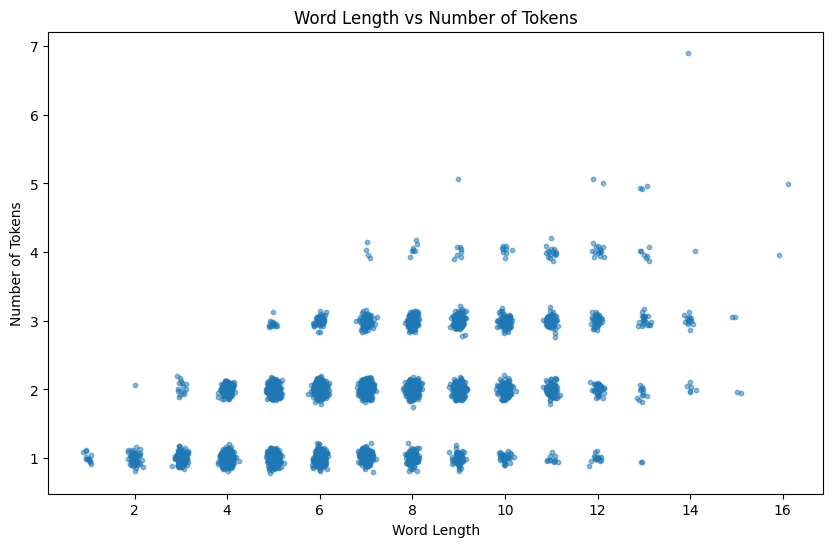

In [40]:
# compare word lengths vs how many tokens they are split into
regex_pattern_split = rf'[{string.punctuation}\s]+' 

words = re.split(regex_pattern_split, book)
words = [item.strip() for item in words if item.strip() != ''] # remove empty strings and strip whitespace

word_token_counts = []
word_lengths = []
for word in set(words):
    token_count = len(tokenizer.encode(word))
    word_token_counts.append(token_count)
    word_lengths.append(len(word))


# bubble scatter plot to see zones with more density of points
offset_x = np.random.randn(len(word_lengths)) / 15
offset_y = np.random.randn(len(word_lengths)) / 15

plt.figure(figsize=(10, 6))
plt.scatter(np.array(word_lengths) + offset_x, np.array(word_token_counts) + offset_y, alpha=0.5, s=10)
plt.xlabel("Word Length")
plt.ylabel("Number of Tokens")
plt.title("Word Length vs Number of Tokens")
plt.show()

# we can see that the more words the more tendency to have more tokens, but it is not always the case.
# some words with 13 characters can be tokenized as a single token, while some words with 5 characters can be tokenized as multiple tokens.

Text(0, 0.5, 'Frequency')

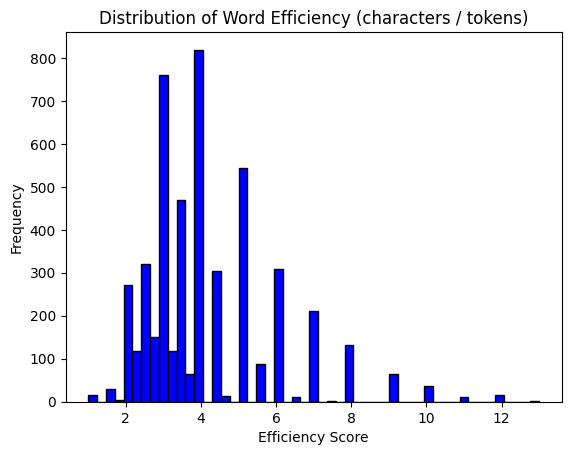

In [41]:
# calcualte word efficiency as the ratio between the number of characters in the word and the number of tokens it is split into.
word_efficiency = [length / tokens for length, tokens in zip(word_lengths, word_token_counts)]

# plot a distribution of word efficiency
plt.hist(word_efficiency, bins="fd", log=False, color='blue', edgecolor='black'); 
# fd is the Freedman-Diaconis rule, which is a method for choosing the number of bins in a histogram that is based on the interquartile 
# range of the data. It is often used to create histograms that are more representative of the underlying distribution of the data, 
# especially when the data has outliers or is not normally distributed.
plt.title("Distribution of Word Efficiency (characters / tokens)")
plt.xlabel("Efficiency Score")
plt.ylabel("Frequency")

In [45]:
# check most inefficient words and most efficient words
efficiency_dict = defaultdict(list)
for word, efficiency in zip(set(words), word_efficiency):
    efficiency_dict[word].append(efficiency)

# sort the efficiency dict by efficiency score
sorted_efficiency = sorted(efficiency_dict.items(), key=lambda x: x[1][0], reverse=True)

# show top 5 most efficient words
print("Top 5 most efficient words:")
for word, efficiency in sorted_efficiency[:5]:
    print(f"Word: '{word}', Efficiency Score: {efficiency[0]:.2f}, Tokens: {tokenizer.encode(word)}")

# show top 5 most inefficient words
print("\nTop 5 most inefficient words:")
for word, efficiency in sorted_efficiency[-5:]:
    print(f"Word: '{word}', Efficiency Score: {efficiency[0]:.2f}, Tokens: {tokenizer.encode(word)}")

Top 5 most efficient words:
Word: 'communication', Efficiency Score: 13.00, Tokens: [51271]
Word: 'advertisement', Efficiency Score: 13.00, Tokens: [94248]
Word: 'constitution', Efficiency Score: 12.00, Tokens: [44103]
Word: 'Introduction', Efficiency Score: 12.00, Tokens: [38255]
Word: 'experimental', Efficiency Score: 12.00, Tokens: [87803]

Top 5 most inefficient words:
Word: 'm', Efficiency Score: 1.00, Tokens: [76]
Word: 'I', Efficiency Score: 1.00, Tokens: [40]
Word: 'a', Efficiency Score: 1.00, Tokens: [64]
Word: 'V', Efficiency Score: 1.00, Tokens: [53]
Word: 'D', Efficiency Score: 1.00, Tokens: [35]


In [23]:
# check those words with 14 characters
for word in set(words):
    if len(word) == 14:
        tokens_split = tokenizer.encode(word)
        words_split = [tokenizer.decode([t]) for t in tokens_split]
        print(f"Word: '{word}', Tokens: {tokens_split}, Which splits into: {words_split}")

Word: 'mathematicians', Tokens: [10590, 12519, 5493], Which splits into: ['math', 'ematic', 'ians']
Word: 'conversational', Tokens: [444, 3078, 1697], Which splits into: ['con', 'vers', 'ational']
Word: 'characteristic', Tokens: [19740, 4633], Which splits into: ['character', 'istic']
Word: 'specialisation', Tokens: [15495, 8082], Which splits into: ['special', 'isation']
Word: 'interpretation', Tokens: [17324, 367], Which splits into: ['interpret', 'ation']
Word: 'expostulations', Tokens: [327, 2252, 7607], Which splits into: ['ex', 'post', 'ulations']
Word: 'Undergrounders', Tokens: [16648, 1993, 388], Which splits into: ['Under', 'ground', 'ers']
Word: 'overwhelmingly', Tokens: [2017, 94179, 398], Which splits into: ['over', 'whelming', 'ly']
Word: 'constellations', Tokens: [1040, 616, 811], Which splits into: ['const', 'ell', 'ations']
Word: 'disinclination', Tokens: [4338, 92257, 2617], Which splits into: ['dis', 'incl', 'ination']
Word: 'differentiated', Tokens: [64750, 10234], W

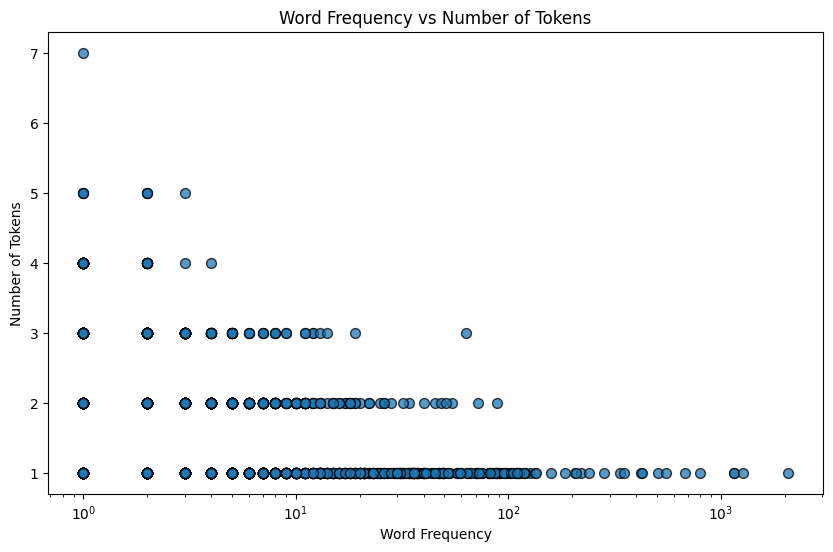

In [51]:
# do more frequent words have fewer tokens?
word_counts = Counter(words)
word_token_counts = []
freq_word = []
for word in set(words):
    freq = word_counts[word]
    token_count = len(tokenizer.encode(word))

    word_token_counts.append(token_count)
    freq_word.append(freq)

plt.figure(figsize=(10, 6))
plt.scatter(freq_word, word_token_counts, alpha=0.75, s=50, edgecolors="k")
plt.xlabel("Word Frequency")
plt.ylabel("Number of Tokens")
plt.title("Word Frequency vs Number of Tokens")
plt.xscale("log")
plt.show()

# we can see that more frequent words tend to have fewer tokens, but there are some exceptions.